In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6" "prophet==1.3.0"

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet
import warnings; warnings.filterwarnings("ignore")
import cmdstanpy; cmdstanpy.utils.get_logger().disabled = True   # 적합 때마다 찍히는 진행 로그를 숨긴다
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
logging.getLogger("prophet").setLevel(logging.WARNING)

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  등록해야 이름이 보인다(등록하지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 31.6 MB/s eta 0:00:00
사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


표 1 · 단순 예측 셋의 예측 원점 5개 RMSE (대)
           계절 나이브 168  계절 나이브 24  시각별 평균
10-19 23시      306.52     398.25  345.51
10-26 23시      418.18     539.28  403.57
11-02 23시      457.07     502.95  516.89
11-09 23시      430.72     318.52  320.53
11-16 23시      205.25     271.23  403.89
원점 5개 평균       363.55     406.05  398.08


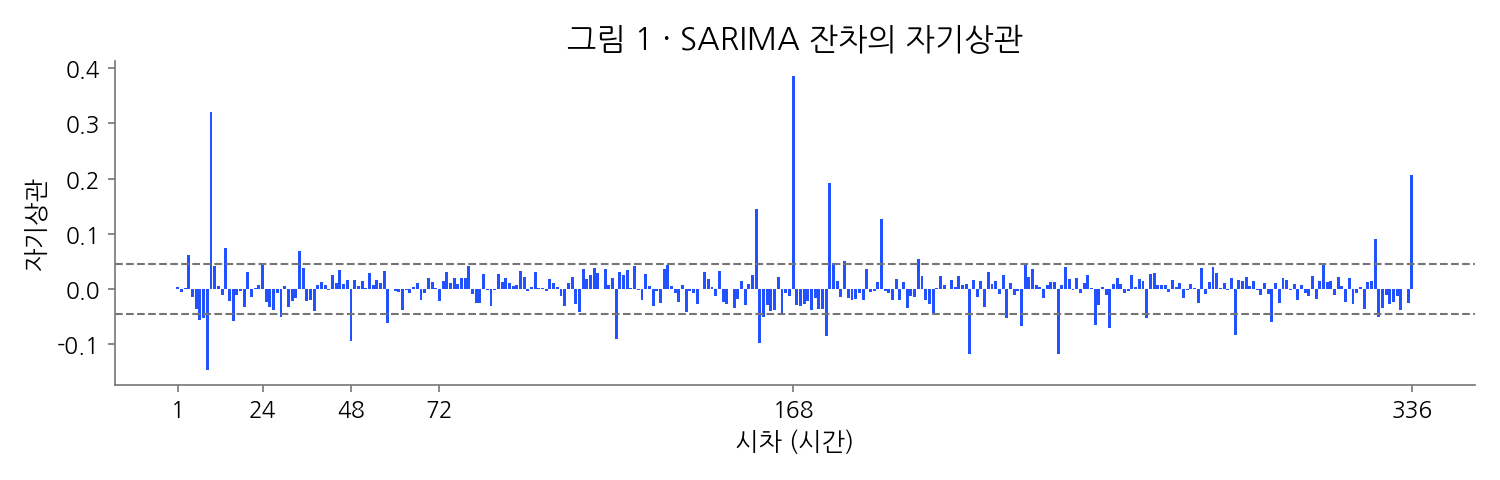

표 2 · SARIMA 잔차 진단 (잔차 1,824개)
  경계선 ±0.046 · 시차 1～336 가운데 경계선 밖 36개
  자기상관이 큰 시차 셋: 168 (0.386) · 10 (0.320) · 336 (0.206)
  시차 1 · 24 의 자기상관: 0.004 · 0.045
  Ljung-Box p 값: 시차 24 3.2e-47 · 시차 168 1.2e-88
표 3 · SARIMA 예측구간이 담은 검증 168시간 (시간)
        담은 시각  상한 위  하한 아래  실제 포함률(%)
명목 95%    162     0      6       96.4
명목 80%    137     0     31       81.5
  검증 168시간 평균: 실측 694.2대 · 점 예측 965.6대
표 4 · 학습 구간과 검증 구간의 기온 (°C)
  학습 1,848시간: 평균 15.8 · 5백분위수 6.2 · 최저 0.8
  검증 168시간: 평균 4.9 · 최저 -3.0
  검증 168시간 가운데 학습 5백분위수보다 추운 시각 101시간
  검증 168시간 가운데 학습 최저보다 추운 시각 23시간
표 5 · 기준 구간 시각별 잔차 중앙값과 MAD (대)
  기준 구간 10월 20일～11월 16일 · 라벨 없는 잔차 599시각
     잔차 중앙값  MAD
0시      -27   84
4시       -4   13
8시      -86  142
13시     -74  175
18시    -301  386


In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1～5 와 그림 1 을 만듭니다. SARIMA 를 한 번 적합해 10～20초 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 값으로 파일 이름 "seoul+bike+sharing+demand.zip" 을 적으세요
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                                                 # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))    # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(168))                                       # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-168))                            # 1주일 전도 휴무면 1주일 뒤 값으로
train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]              # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]              # 검증 168시간

# 표 1: 단순 예측 셋을 예측 원점 5개(금요일 23시)에서 168시간씩 채점한다
ORIGINS = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")
dem_all = df["demand"].astype(float)
origin_rows = {}
for o in ORIGINS:
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")   # 원점 1시간 뒤부터 168시간
    last_day = dem_all.loc[o - pd.Timedelta(hours=23):o].to_numpy()          # 원점 전 마지막 하루 24시각
    fit_part = dem_all.loc["2018-09-01 00:00":o]
    hour_mean = fit_part.groupby(fit_part.index.hour).mean()                  # 9월 1일～원점의 시각별 평균
    origin_rows[f"{o:%m-%d} 23시"] = {
        "계절 나이브 168": rmse(dem_all.loc[week], dem_all.shift(168).loc[week]),
        "계절 나이브 24": rmse(dem_all.loc[week], np.tile(last_day, 7)),
        "시각별 평균": rmse(dem_all.loc[week], hour_mean.loc[week.hour].to_numpy())}
origin_rmse = pd.DataFrame(origin_rows).T
origin_rmse.loc["원점 5개 평균"] = origin_rmse.mean()
print("표 1 · 단순 예측 셋의 예측 원점 5개 RMSE (대)")
print(origin_rmse.round(2).to_string())

# 그림 1 · 표 2: 학습 1,848시간에 셋째 날 SARIMA 를 적합하고 잔차를 진단한다
sarima_res = SARIMAX(train["demand"], order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
sarima_resid = sarima_res.resid.iloc[24:]                          # 앞 24시각은 계절차분 초기값이라 뺀다
resid_acf = acf(sarima_resid, nlags=336)
acf_bound = 1.96 / np.sqrt(len(sarima_resid))
resid_top3 = (np.argsort(-np.abs(resid_acf[1:]))[:3] + 1).tolist()  # 절댓값이 큰 시차 셋
lb_p = acorr_ljungbox(sarima_resid, lags=[24, 168], model_df=4)["lb_pvalue"].to_numpy()
fig, ax = plt.subplots(figsize=(FIG_W, 3.2))
ax.bar(range(1, 337), resid_acf[1:], width=0.8, color=COL["파랑"])
ax.axhline(acf_bound, color=COL["회색"], ls="--", lw=1)
ax.axhline(-acf_bound, color=COL["회색"], ls="--", lw=1)
ax.set_xticks([1, 24, 48, 72, 168, 336])
ax.set_title("그림 1 · SARIMA 잔차의 자기상관")
ax.set_xlabel("시차 (시간)")
ax.set_ylabel("자기상관")
plt.show()
print("표 2 · SARIMA 잔차 진단 (잔차 1,824개)")
print(f"  경계선 ±{acf_bound:.3f} · 시차 1～336 가운데 경계선 밖 {int((np.abs(resid_acf[1:]) > acf_bound).sum())}개")
print("  자기상관이 큰 시차 셋: " + " · ".join(f"{k} ({resid_acf[k]:.3f})" for k in resid_top3))
print(f"  시차 1 · 24 의 자기상관: {resid_acf[1]:.3f} · {resid_acf[24]:.3f}")
print(f"  Ljung-Box p 값: 시차 24 {lb_p[0]:.1e} · 시차 168 {lb_p[1]:.1e}")

# 표 3: 같은 SARIMA 로 검증 168시간을 한 번에 예측하고 예측구간이 실측을 몇 시각 담았는지 센다
sarima_fc = sarima_res.get_forecast(steps=len(valid))
valid_act = valid["demand"].to_numpy()
cover_rows = {}
for nominal, alpha in [("명목 95%", 0.05), ("명목 80%", 0.20)]:       # alpha 는 유의수준, 명목 포함률 = 1 − alpha
    ci = sarima_fc.conf_int(alpha=alpha)
    lo, hi = ci.iloc[:, 0].to_numpy(), ci.iloc[:, 1].to_numpy()
    n_in = int(((valid_act >= lo) & (valid_act <= hi)).sum())
    cover_rows[nominal] = {"담은 시각": n_in, "상한 위": int((valid_act > hi).sum()),
                           "하한 아래": int((valid_act < lo).sum()),
                           "실제 포함률(%)": round(100 * n_in / len(valid_act), 1)}
cover_table = pd.DataFrame.from_dict(cover_rows, orient="index")   # 행 = 명목 포함률
pred_mean = float(sarima_fc.predicted_mean.mean())
print("표 3 · SARIMA 예측구간이 담은 검증 168시간 (시간)")
print(cover_table.to_string())
print(f"  검증 168시간 평균: 실측 {valid_act.mean():.1f}대 · 점 예측 {pred_mean:.1f}대")

# 표 4: 검증 168시간의 기온이 학습 1,848시간 기온 범위 안인지 본다
temp_train = train["temp"].astype(float)
temp_valid = valid["temp"].astype(float)
temp_p5 = float(np.percentile(temp_train, 5))                      # 학습 기온의 5백분위수
n_cold = int((temp_valid < temp_p5).sum())
n_below_min = int((temp_valid < temp_train.min()).sum())
print("표 4 · 학습 구간과 검증 구간의 기온 (°C)")
print(f"  학습 1,848시간: 평균 {temp_train.mean():.1f} · 5백분위수 {temp_p5:.1f} · 최저 {temp_train.min():.1f}")
print(f"  검증 168시간: 평균 {temp_valid.mean():.1f} · 최저 {temp_valid.min():.1f}")
print(f"  검증 168시간 가운데 학습 5백분위수보다 추운 시각 {n_cold}시간")
print(f"  검증 168시간 가운데 학습 최저보다 추운 시각 {n_below_min}시간")

# 표 5: 기준 구간(10월 20일～11월 16일)의 라벨 없는 잔차로 시각별 중앙값과 MAD 를 구한다
resid_base = df["count"].astype(float) - dem_all.shift(168)        # 잔차 = 실측 − 1주일 전 보정 수요
label_hour = df["functioning"].eq("No") | (df["rain"].astype(float) >= 10)   # 정답 라벨: 휴무 · 시간당 강수 10mm 이상
in_base = pd.Series((df.index >= pd.Timestamp("2018-10-20 00:00"))
                    & (df.index <= pd.Timestamp("2018-11-16 23:00")), index=df.index)
base_part = pd.DataFrame({"r": resid_base, "h": df.index.hour}, index=df.index)[
    in_base & ~label_hour & resid_base.notna()]
med_by_hour = base_part.groupby("h")["r"].median()                  # 시각별 잔차 중앙값 24개
mad_by_hour = base_part.groupby("h")["r"].apply(lambda s: float(np.median(np.abs(s - s.median()))))
hour_table = pd.DataFrame({"잔차 중앙값": med_by_hour, "MAD": mad_by_hour}).loc[[0, 4, 8, 13, 18]]
hour_table.index = [f"{h}시" for h in hour_table.index]
print("표 5 · 기준 구간 시각별 잔차 중앙값과 MAD (대)")
print(f"  기준 구간 10월 20일～11월 16일 · 라벨 없는 잔차 {len(base_part)}시각")
print(hour_table.round(0).astype(int).to_string())

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
# [heavy] 셋째 날 SARIMA 를 원점마다 재적합해 1분 안팎 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

FIT_START = "2018-09-01 00:00"                                       # 학습은 원점마다 9월 1일 0시부터
ORIGINS = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")   # 금요일 23시 원점 5개
CAND_NAMES = ["셋째 날 SARIMA", "다섯째 날 Prophet 기본 구성"]
FC = {name: [] for name in CAND_NAMES}                               # 후보마다 원점별 168시간 예측
prev_params = None                                                   # 첫 원점은 기본 출발값에서 추정한다
for o in ORIGINS:
    fit_part = df.loc[FIT_START:o, "demand"]                          # 9월 1일부터 원점까지로 재적합
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")   # 원점 1시간 뒤부터 168시간
    sar = SARIMAX(fit_part, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(
        disp=False, start_params=prev_params)
    prev_params = sar.params                                         # 다음 원점은 이 계수에서 출발해 다시 추정한다
    FC["셋째 날 SARIMA"].append(pd.Series(np.asarray(sar.forecast(168), dtype=float), index=week))
    pro = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                  holidays=holidays_one, uncertainty_samples=0)       # 구간 없이 예측값만 낸다
    pro.fit(pd.DataFrame({"ds": fit_part.index, "y": fit_part.values}))
    FC["다섯째 날 Prophet 기본 구성"].append(
        pd.Series(pro.predict(pd.DataFrame({"ds": week}))["yhat"].to_numpy(), index=week))
    print(f"  원점 {o:%m-%d %H}시 · 학습 {len(fit_part):,}시간으로 두 후보 적합 완료")

print(f"예측 원점 {len(ORIGINS)}개 · 후보 {len(CAND_NAMES)}개 : " + " · ".join(CAND_NAMES))
print("FC[이름][k] : k번째 원점 1시간 뒤부터 168시간의 예측 (인덱스가 그 168시각)")
print("쓸 수 있는 이름 : df (열 demand) · ORIGINS · CAND_NAMES · FC · rmse(a, b)")

  원점 10-19 23시 · 학습 1,176시간으로 두 후보 적합 완료
  원점 10-26 23시 · 학습 1,344시간으로 두 후보 적합 완료
  원점 11-02 23시 · 학습 1,512시간으로 두 후보 적합 완료
  원점 11-09 23시 · 학습 1,680시간으로 두 후보 적합 완료
  원점 11-16 23시 · 학습 1,848시간으로 두 후보 적합 완료
예측 원점 5개 · 후보 2개 : 셋째 날 SARIMA · 다섯째 날 Prophet 기본 구성
FC[이름][k] : k번째 원점 1시간 뒤부터 168시간의 예측 (인덱스가 그 168시각)
쓸 수 있는 이름 : df (열 demand) · ORIGINS · CAND_NAMES · FC · rmse(a, b)


원점 10-19 23시 · 계절 나이브 168 306.52 · 셋째 날 SARIMA 345.39 · 다섯째 날 Prophet 기본 구성 366.49 · 가장 작은 예측: 계절 나이브 168
원점 10-26 23시 · 계절 나이브 168 418.18 · 셋째 날 SARIMA 368.10 · 다섯째 날 Prophet 기본 구성 410.68 · 가장 작은 예측: 셋째 날 SARIMA
원점 11-02 23시 · 계절 나이브 168 457.07 · 셋째 날 SARIMA 508.05 · 다섯째 날 Prophet 기본 구성 474.90 · 가장 작은 예측: 계절 나이브 168
원점 11-09 23시 · 계절 나이브 168 430.72 · 셋째 날 SARIMA 317.68 · 다섯째 날 Prophet 기본 구성 342.82 · 가장 작은 예측: 셋째 날 SARIMA
원점 11-16 23시 · 계절 나이브 168 205.25 · 셋째 날 SARIMA 386.07 · 다섯째 날 Prophet 기본 구성 310.42 · 가장 작은 예측: 계절 나이브 168

채택 예측의 원점 5개 평균 RMSE = 363.55 대
베이스라인보다 원점 5개 평균 RMSE 가 작은 후보 수 = 0 개
보고: 채택 예측 계절 나이브 168 · 채점 조건 — 예측 원점 5개 · 학습 9월 1일~원점 · 예측 기간 168시간 · 지표 RMSE


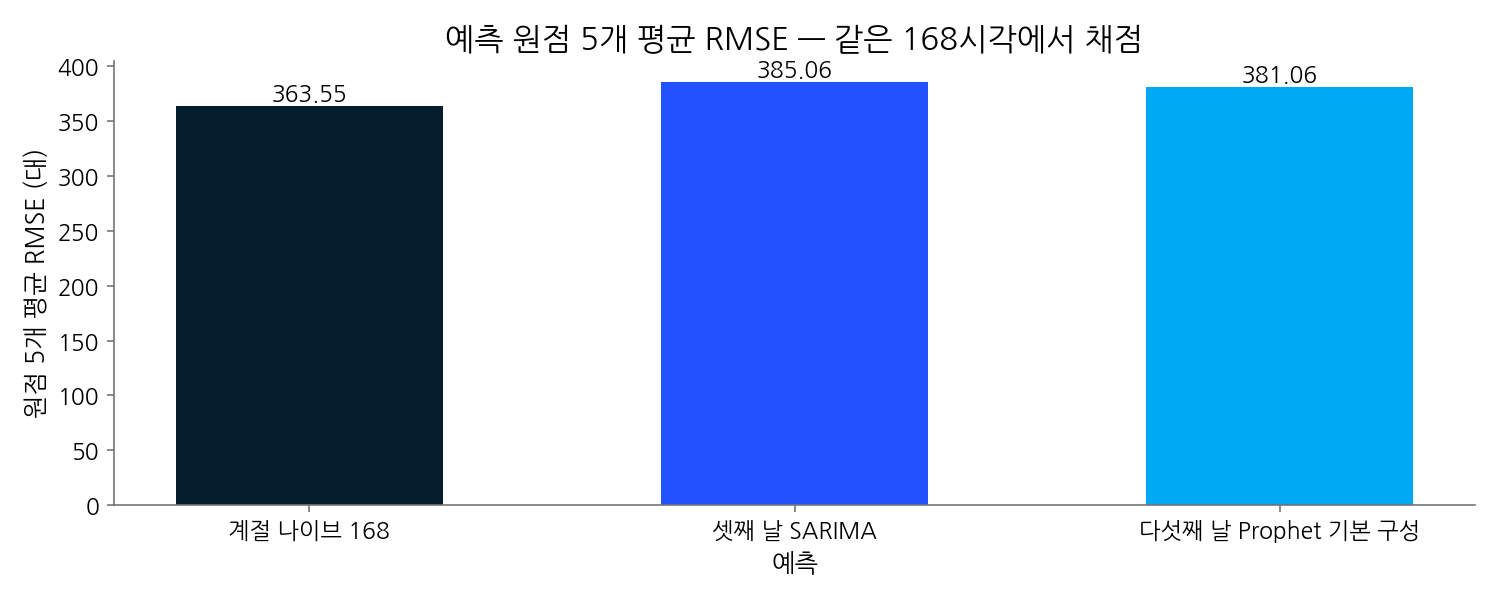

In [4]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
미션 1 준비 셀이 만든 df, ORIGINS, CAND_NAMES, FC, rmse 를 그대로 써 줘.
이 이름들은 다시 만들지 말고, SARIMA 와 Prophet 도 재적합하지 마.

1. 예측 원점 5개마다 FC[이름][k].index 의 168시각을 채점 시각으로 잡아.
   그 같은 168시각에서 실측 df["demand"] 와 예측 셋의 RMSE 를 rmse(a, b) 로 구해.
   예측 셋은 df["demand"].shift(168) 로 꺼낸 "계절 나이브 168" 과 CAND_NAMES 의 후보 2개야.
   후보 두 개의 인덱스가 같은 168시각인지도 확인해 줘.
2. 원점마다 세 RMSE 와 그 원점에서 가장 작게 빗나간 예측 이름을 한 행씩 출력해 줘.
3. 원점 5개 평균 RMSE 가 가장 작은 예측을 채택하고, 아래 두 값을 「이름 = 값 단위」 한 행씩 출력해 줘.
   채택 예측의 원점 5개 평균 RMSE = 값 대   (소수 둘째 자리)
   베이스라인보다 원점 5개 평균 RMSE 가 작은 후보 수 = 값 개   (정수)
4. 보고 한 행: 채택한 예측 이름과 채점 조건(예측 원점 5개 · 학습 9월 1일~원점 · 예측 기간 168시간 · 지표 RMSE)을 출력해 줘.
5. 원점 5개 평균 RMSE 막대그래프 한 장: 막대 3개, 가로축 「예측」, 세로축 「원점 5개 평균 RMSE (대)」.
   폭은 FIG_W, 색은 COL 을 쓰고 베이스라인은 남색으로, 막대 위에 값을 적어 줘.
"""
# --- 여기부터 AI 코드 ---
BASE = "계절 나이브 168"
ALL_NAMES = [BASE] + CAND_NAMES
dem = df["demand"].astype(float)
naive168 = dem.shift(168)                                    # 1주일 전 같은 시각 값

# 1·2. 원점마다 같은 168시각에서 세 예측을 채점한다
rows = {}
for k, o in enumerate(ORIGINS):
    idx = FC[CAND_NAMES[0]][k].index                         # 원점 1시간 뒤부터 168시각
    for name in CAND_NAMES:
        assert FC[name][k].index.equals(idx), f"{name} 의 {k}번째 인덱스가 다릅니다"
    actual = dem.loc[idx]
    row = {BASE: rmse(actual, naive168.loc[idx])}
    for name in CAND_NAMES:
        row[name] = rmse(actual, FC[name][k].loc[idx])
    rows[f"{o:%m-%d %H}시"] = row

score = pd.DataFrame(rows).T[ALL_NAMES]
for label, r in score.iterrows():
    vals = " · ".join(f"{n} {r[n]:.2f}" for n in ALL_NAMES)
    print(f"원점 {label} · {vals} · 가장 작은 예측: {r.idxmin()}")

# 3. 원점 5개 평균으로 채택한다 (이긴 횟수가 아니라 평균)
mean_rmse = score.mean()
best = mean_rmse.idxmin()
n_better = int((mean_rmse[CAND_NAMES] < mean_rmse[BASE]).sum())
print()
print(f"채택 예측의 원점 5개 평균 RMSE = {mean_rmse[best]:.2f} 대")
print(f"베이스라인보다 원점 5개 평균 RMSE 가 작은 후보 수 = {n_better} 개")

# 4. 보고 한 행
print(f"보고: 채택 예측 {best} · 채점 조건 — 예측 원점 5개 · 학습 9월 1일~원점 · "
      f"예측 기간 168시간 · 지표 RMSE")

# 5. 원점 5개 평균 RMSE 막대 3개
fig, ax = plt.subplots(figsize=(FIG_W, 4.0))
colors = [COL["남색"], COL["파랑"], COL["하늘색"]]
bars = ax.bar(ALL_NAMES, mean_rmse[ALL_NAMES].to_numpy(), color=colors, width=0.55)
for b, v in zip(bars, mean_rmse[ALL_NAMES]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom")
ax.set_xlabel("예측")
ax.set_ylabel("원점 5개 평균 RMSE (대)")
ax.set_title("예측 원점 5개 평균 RMSE — 같은 168시각에서 채점")
plt.show()

In [5]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다

_missing = [_n for _n in ("pd", "np", "plt", "datefmt") if _n not in globals()]
if _missing:                                                       # 맨 위 설치 셀을 아직 실행하지 않았습니다
    raise NameError("맨 위 설치 셀을 먼저 실행하세요 — 아직 없는 이름 "
                    + " · ".join(_missing))
if "judge" not in globals():                                       # 막지는 않고 알리기만 합니다
    print("ⓘ 맨 위 [채점] 셀을 아직 실행하지 않았습니다 — 그 셀을 한 번 실행해야"
          " 「PROMPT 셀」 아래에 채점 결과와 힌트가 나옵니다")

URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무 295시간은 결측으로 본다
_y = _s.fillna(_s.shift(24 * 7))
df["demand"] = _y.fillna(_y.shift(-24 * 7))                       # 1주일 전후 같은 시각으로 보정

TRAIN_END = "2018-11-16 23:00"                                    # 예측 원점: 이 시각까지의 실측만 씁니다
BASE_START = "2018-10-20 00:00"                                   # 기준 구간의 시작: 원점까지 마지막 4주
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]             # 다음 주 168시각 = 계획표의 행
plan = pd.DataFrame(index=valid.index)
plan.index.name = "시각"

# 여섯째 날 레퍼런스가 잔차의 실측으로 쓰는 원본 대여 수 count (계획표 168시각은 휴무가 없어 보정 수요와 같다)
CNT = df["count"].astype(float)
DEM = df["demand"].astype(float)                                  # 기댓값을 만들 보정 수요
HOUR = pd.Series(df.index.hour, index=df.index)
LABEL = df["functioning"].eq("No") | (df["rain"].astype(float) >= 10)   # 정답 라벨: 휴무 · 시간당 강수 10mm 이상
IN_BASE = pd.Series((df.index >= pd.Timestamp(BASE_START))
                    & (df.index <= pd.Timestamp(TRAIN_END)), index=df.index)
RESID = CNT - DEM.shift(168)                                       # 잔차 = 실측 − 1주일 전 같은 시각의 보정 수요
_base = pd.DataFrame({"r": RESID, "h": HOUR})[IN_BASE & ~LABEL & RESID.notna()]
_g = _base.groupby("h")["r"]
MED_H = _g.median()                                                # 기준 구간의 시각별 잔차 중앙값 24개
MAD_H = _g.apply(lambda s: float(np.median(np.abs(s - s.median()))))   # 기준 구간의 시각별 MAD 24개
ALERTS = (3.5, 4, 5)                                               # 비교할 임계값 3개

# 본문이 인용하는 수를 확인합니다
_n_base = int(IN_BASE.sum())
assert _n_base == 672 and len(_base) == 599 and len(plan) == 168
assert MAD_H[0] == 84 and MAD_H[4] == 13 and MED_H[8] == -86 and MAD_H[8] == 142
assert (CNT.loc[plan.index] == DEM.loc[plan.index]).all()
assert DEM.shift(168).loc[pd.Timestamp("2018-11-17 00:00")] == 754

print(f"기준 구간 : {BASE_START[:10]} 0시 ~ {TRAIN_END[:10]} 23시 · {_n_base}시간 · {_n_base // 24}일")
print(f"라벨 없는 기준 구간 잔차 : {len(_base)}시간 → 시각별 중앙값 MED_H · MAD MAD_H 24개씩")
print(f"계획표 plan : {plan.index[0]:%m-%d %H}시 ~ {plan.index[-1]:%m-%d %H}시 · 아직 열 없음")
print("쓸 수 있는 이름 : plan · CNT · DEM · RESID · HOUR · LABEL · IN_BASE"
      " · MED_H · MAD_H · ALERTS · datefmt")

ⓘ 맨 위 [채점] 셀을 아직 실행하지 않았습니다 — 그 셀을 한 번 실행해야 「PROMPT 셀」 아래에 채점 결과와 힌트가 나옵니다
기준 구간 : 2018-10-20 0시 ~ 2018-11-16 23시 · 672시간 · 28일
라벨 없는 기준 구간 잔차 : 599시간 → 시각별 중앙값 MED_H · MAD MAD_H 24개씩
계획표 plan : 11-17 00시 ~ 11-23 23시 · 아직 열 없음
쓸 수 있는 이름 : plan · CNT · DEM · RESID · HOUR · LABEL · IN_BASE · MED_H · MAD_H · ALERTS · datefmt


임계값 3.5 에서 기준 구간 하루 오탐 수 = 2.43 건
임계값 4 에서 기준 구간 하루 오탐 수 = 1.64 건
임계값 5 에서 기준 구간 하루 오탐 수 = 0.75 건
하루 오탐 수 상한 1건 → 고른 임계값 ALERT = 5

다음 주 168시각 가운데 이상으로 탐지된 시각 = 0 시각


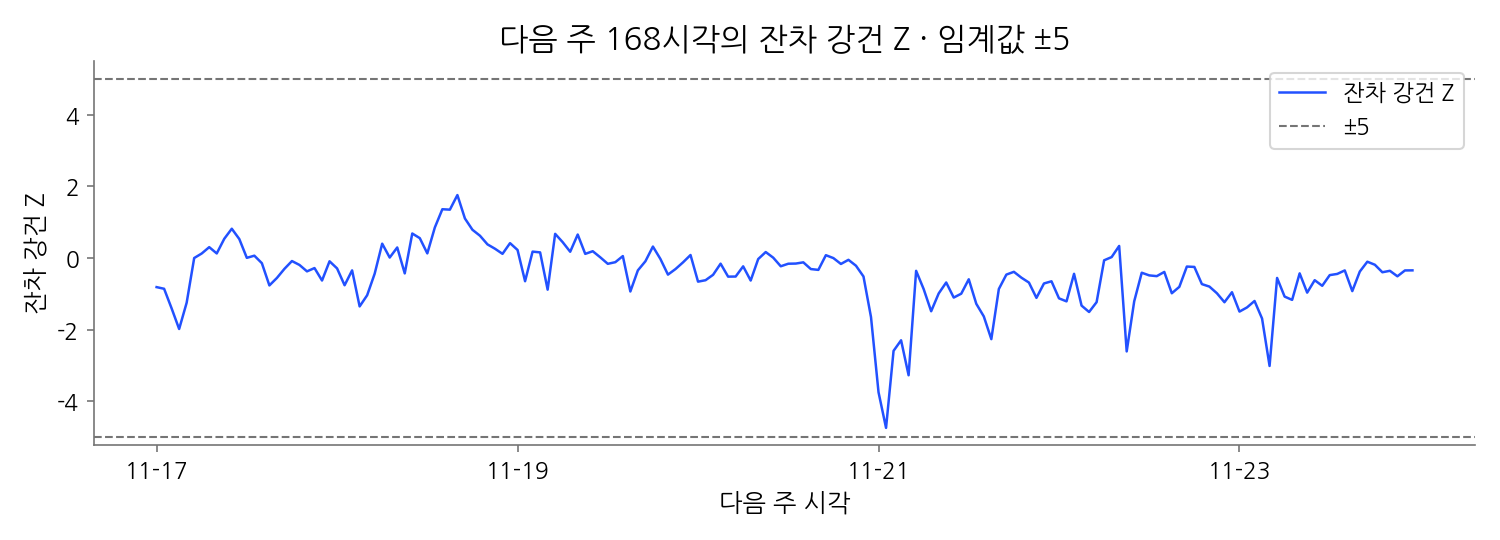

In [6]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
미션 2 준비 셀이 만든 plan, CNT, DEM, RESID, HOUR, LABEL, IN_BASE, MED_H, MAD_H, ALERTS, datefmt 를
그대로 써 줘. 이 이름들은 다시 만들지 마.

1. 예측 열: DEM.shift(168) 에서 plan.index 의 168시각을 골라 plan["예측"] 으로 둬.
2. 기준 구간 하루 오탐 수:
   기준 구간 잔차는 RESID 를 쓰고, 행마다 그 시각(HOUR)의 MED_H · MAD_H 로
   강건 Z = 0.6745 × (잔차 − 그 시각 중앙값) ÷ 그 시각 MAD 를 구해.
   IN_BASE 가 참이고 LABEL 이 거짓이고 RESID 가 결측이 아닌 시각만 써.
   ALERTS 의 임계값마다 강건 Z 절댓값이 임계값을 넘은 시각 수를
   날짜 수(IN_BASE 의 시간 수 ÷ 24)로 나눠,
   「임계값 3.5 에서 기준 구간 하루 오탐 수 = 값 건」 형식으로 한 행씩 출력해 줘 (소수 둘째 자리).
3. 임계값 고르기: 하루 오탐 수 상한은 CAP 변수로 둬 (내가 정한 값: 1건).
   하루 오탐 수가 CAP 이하인 임계값 가운데 가장 작은 것을 ALERT 에 담아.
   조건을 채우는 임계값이 없으면 가장 큰 임계값을 쓰고 그 사실을 출력해 줘.
4. 이상 열: 계획표 168시각의 잔차는 CNT 에서 plan["예측"] 을 뺀 값으로 하고,
   같은 식으로 그 시각의 MED_H · MAD_H 로 강건 Z 를 구해 plan["강건 Z"] 로 둬.
   절댓값이 ALERT 를 넘으면 plan["이상"] 을 참으로 적어 줘.
   이상으로 탐지된 시각 수와 그 시각들의 실측 · 예측 · 강건 Z 도 출력해 줘.
5. 그래프 한 장: plan["강건 Z"] 를 그대로 선 하나로 그리고, ±ALERT 가로선을 그려 줘.
   가로축 「다음 주 시각」, 세로축 「잔차 강건 Z」. 폭은 FIG_W, 색은 COL, 날짜 눈금은 datefmt 를 써.
"""
# --- 여기부터 AI 코드 ---
CAP = 1                                                     # 내가 정한 하루 오탐 수 상한 (1, 2, 3 가운데)

def robust_z(resid, hours):
    """그 시각의 중앙값과 MAD 로 잔차를 표준화한다"""
    med = MED_H.loc[hours].to_numpy()
    mad = MAD_H.loc[hours].to_numpy()
    return 0.6745 * (np.asarray(resid, dtype=float) - med) / mad

# 1. 예측 열: 계절 나이브 168
plan["예측"] = DEM.shift(168).loc[plan.index]

# 2. 기준 구간(라벨 없는 시각)의 하루 오탐 수
base_mask = IN_BASE & ~LABEL & RESID.notna()
z_base = pd.Series(robust_z(RESID[base_mask], HOUR[base_mask]), index=RESID[base_mask].index)
n_days = int(IN_BASE.sum()) / 24                            # 672시간 / 24 = 28일
fa_per_day = {}
for a in ALERTS:
    fa_per_day[a] = int((z_base.abs() > a).sum()) / n_days
    print(f"임계값 {a} 에서 기준 구간 하루 오탐 수 = {fa_per_day[a]:.2f} 건")

# 3. 상한을 채우는 가장 작은 임계값
ok = [a for a in sorted(ALERTS) if fa_per_day[a] <= CAP]
if ok:
    ALERT = ok[0]
else:
    ALERT = max(ALERTS)
    print(f"ⓘ 하루 {CAP}건 이하를 채우는 임계값이 없어 가장 큰 {ALERT} 를 씁니다")
print(f"하루 오탐 수 상한 {CAP}건 → 고른 임계값 ALERT = {ALERT}")

# 4. 이상 열: 계획표 168시각의 강건 Z
plan_resid = CNT.loc[plan.index] - plan["예측"]
plan["강건 Z"] = robust_z(plan_resid, plan.index.hour)
plan["이상"] = plan["강건 Z"].abs() > ALERT

flagged = plan[plan["이상"]]
print(f"\n다음 주 168시각 가운데 이상으로 탐지된 시각 = {len(flagged)} 시각")
if len(flagged):
    show = pd.DataFrame({"실측": CNT.loc[flagged.index], "예측": flagged["예측"],
                         "강건 Z": flagged["강건 Z"].round(2)})
    print(show.to_string())

# 5. 강건 Z 선과 ±ALERT 가로선
fig, ax = plt.subplots(figsize=(FIG_W, 3.6))
ax.plot(plan.index, plan["강건 Z"], color=COL["파랑"], lw=1.2, label="잔차 강건 Z")
ax.axhline(ALERT, color=COL["회색"], ls="--", lw=1, label=f"±{ALERT}")
ax.axhline(-ALERT, color=COL["회색"], ls="--", lw=1)
ax.set_xlabel("다음 주 시각")
ax.set_ylabel("잔차 강건 Z")
ax.set_title(f"다음 주 168시각의 잔차 강건 Z · 임계값 ±{ALERT}")
datefmt(ax)
ax.legend(loc="upper right")
plt.show()